https://www.kaggle.com/datasets/willianoliveiragibin/independent-predictors-postoperative/data

# Predictores independentes pós-operatórios

**Delírio em pacientes idosos submetidos à cirurgia ortopédica e anestesiados com ciprofloxacino.**

# Sobre o conjunto de dados

Este conjunto de dados contém registros clínicos anonimizados de 337 pacientes idosos (idade ≥ 65 anos) submetidos a cirurgia ortopédica eletiva sob anestesia geral com o anestésico intravenoso Ciprofloxacino. Os dados foram coletados para investigar fatores de risco para delirium pós-operatório (DPO). Inclui variáveis ​​abrangentes pré, intra e pós-operatórias, como informações demográficas, escores de depressão e fragilidade, detalhes cirúrgicos, profundidade anestésica (BIS), resultados laboratoriais (marcadores inflamatórios, nutricionais e renais) e novos biomarcadores de lesão neural baseados em sangue (cadeia leve de neurofilamento e GFAP). O desfecho primário é a incidência de DPO (19,9%), avaliada pelo Método de Avaliação da Confusão (CAM). A análise identificou preditores independentes importantes, incluindo escores mais altos na Escala de Depressão Geriátrica, menor Índice Prognóstico Nutricional, níveis elevados de NfL pós-operatório e maior fragmentação do sono. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Independent Predictors of Postoperative new.csv', decimal=',')

# EAD

In [2]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   编号                               336 non-null    int64  
 1   年龄                               336 non-null    int64  
 2   性别                               336 non-null    object 
 3   体重指数（BMI）                        336 non-null    float64
 4   合并症指数（CCI）                       336 non-null    int64  
 5   简易认知测验（Mini-Cog）                 336 non-null    int64  
 6   老年抑郁量表（GDS-15）                   336 non-null    int64  
 7   临床衰弱量表（CFS）                      336 non-null    int64  
 8   白蛋白（Alb，g/L）                     336 non-null    float64
 9   淋巴细胞计数（×10⁹/L）                   336 non-null    float64
 10  营养指数（PNI）                        336 non-null    float64
 11  环泊酚平均剂量（mg/kg/h）                 336 non-null    float64
 12  瑞芬太尼用量（μg/kg/min）     

,编号,年龄,性别,体重指数（BMI）,合并症指数（CCI）,简易认知测验（Mini-Cog）,老年抑郁量表（GDS-15）,临床衰弱量表（CFS）,白蛋白（Alb，g/L）,淋巴细胞计数（×10⁹/L）,...,胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）,胶质纤维酸性蛋白术后水平（GFAP_post，pg/mL）,术后首夜睡眠破碎指数（夜间干扰次数）,术后谵妄（POD，0=无，1=有）,住院天数（d）,并发症（0=无，1=有）,30日再入院（0=否，1=是）,30日死亡（0=否，1=是）,6个月认知结局（无下降/轻度下降/中重度下降）,截至2025年7月随访生存状态（0=生存，1=死亡）
0,146,79,Male,27.2,3,2,5,7,36.2,1.67,...,86.5,101.7,2,0,14,1,0,0,Moderate/Severe,0
1,52,72,Male,25.1,2,3,4,7,34.8,2.34,...,100.6,109.7,2,0,14,0,0,0,No decline,0
2,325,68,Female,25.8,2,3,5,5,44.8,1.93,...,85.6,99.5,4,0,14,0,0,0,Moderate/Severe,0
3,318,73,Female,26.0,1,4,6,7,34.7,1.59,...,83.7,93.3,3,1,12,0,0,0,No decline,0
4,14,63,Male,23.4,0,3,2,4,39.2,2.27,...,78.7,90.9,6,0,8,0,0,0,No decline,0


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\320838837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, palette='Set2')


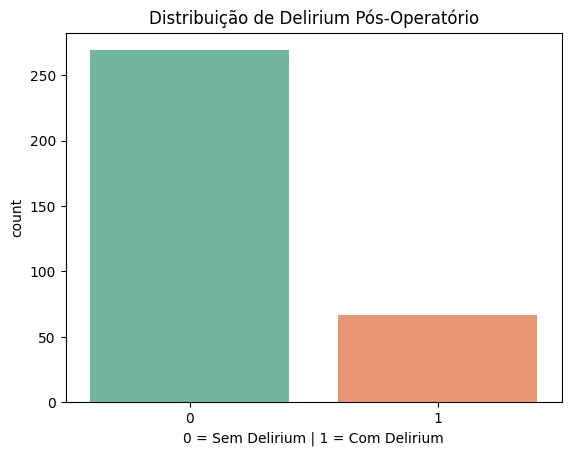

In [3]:
#Limpeza
df.columns = df.columns.str.strip()

target = '术后谵妄（POD，0=无，1=有）'

#Visualizar a distribuição
sns.countplot(x=target, data=df, palette='Set2')
plt.title('Distribuição de Delirium Pós-Operatório')
plt.xlabel('0 = Sem Delirium | 1 = Com Delirium')
plt.show()

# ML

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

features = [
    '年龄', '体重指数（BMI）', '合并症指数（CCI）', 
    '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）', 
    '胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）',
    '平均BIS值', '手术时长（min）'
]

#Criando a matriz X (preditores) e o vetor y (alvo)
X = df[features]
y = df[target]

#Verificar se há valores nulos
print(X.isna().sum())

年龄                              0
体重指数（BMI）                       0
合并症指数（CCI）                      0
神经丝轻链蛋白术前水平（NfL_pre，pg/mL）      0
胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）    0
平均BIS值                          0
手术时长（min）                       0
dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\3952378047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y='神经丝轻链蛋白术前水平（NfL_pre，pg/mL）', data=df, palette='Set2')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\3952378047.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y='胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）', data=df, palette='Set3')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\3952378047.py:12: UserWarning: Glyph 26415 (\N{CJK UNIFIED IDEOGRAPH-672F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\3952378047.py:12: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Deja

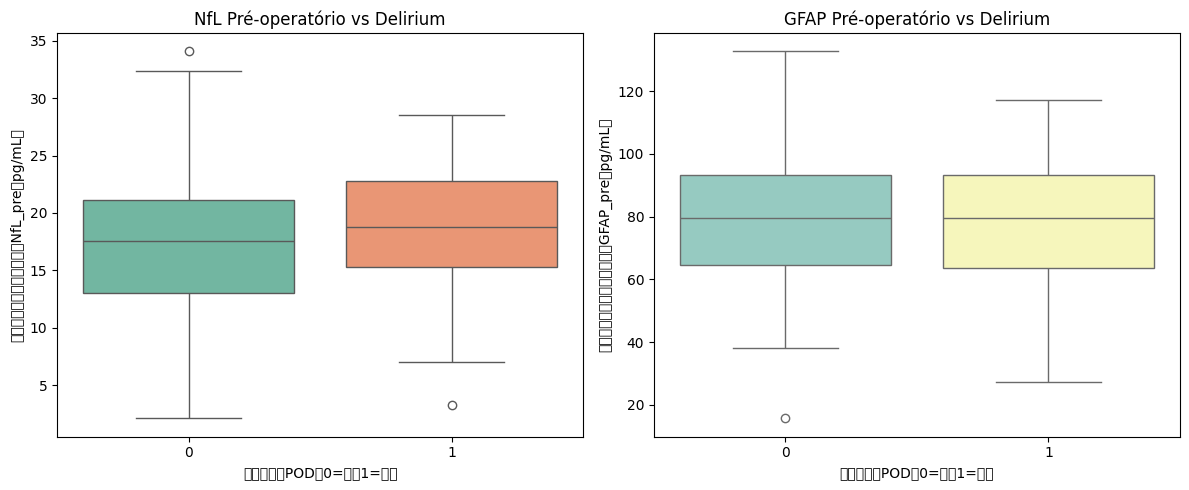

In [5]:
#Comparação visual de biomarcadores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=target, y='神经丝轻链蛋白术前水平（NfL_pre，pg/mL）', data=df, palette='Set2')
plt.title('NfL Pré-operatório vs Delirium')

plt.subplot(1, 2, 2)
sns.boxplot(x=target, y='胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）', data=df, palette='Set3')
plt.title('GFAP Pré-operatório vs Delirium')

plt.tight_layout()
plt.show()

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.79      1.00      0.89        54
           1       0.00      0.00      0.00        14

    accuracy                           0.79        68
   macro avg       0.40      0.50      0.44        68
weighted avg       0.63      0.79      0.70        68

AUC-ROC (Capacidade Preditiva): 0.50


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

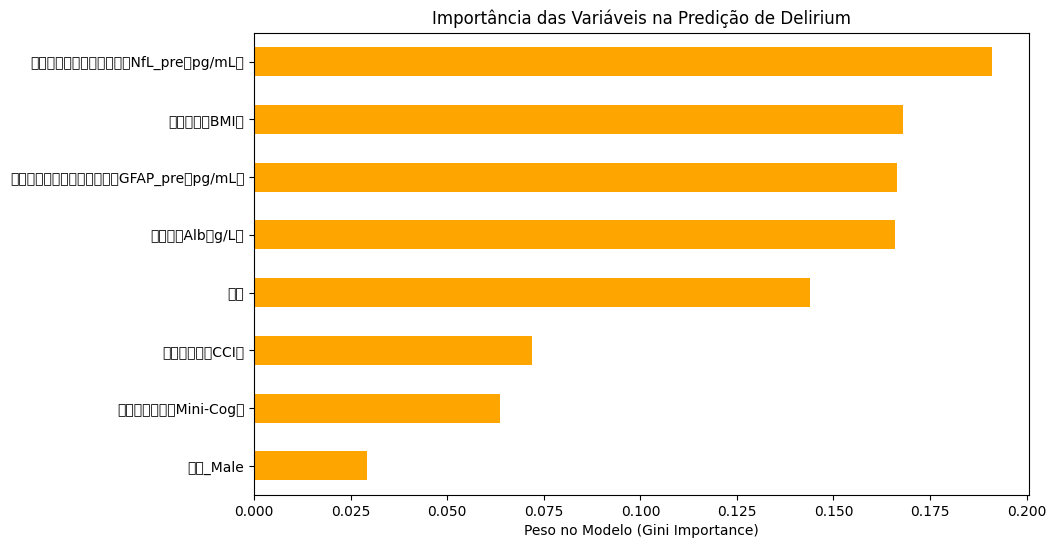

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Limpeza 
df.columns = df.columns.str.strip()

#Seleção de Features e Alvo
target = '术后谵妄（POD，0=无，1=有）'
#Selecionando as colunas mais relevantes para pesquisa neurocognitiva
features = [
    '年龄', '性别', '体重指数（BMI）', '合并症指数（CCI）', 
    '简易认知测验（Mini-Cog）', '白蛋白（Alb，g/L）', 
    '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）', 
    '胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）'
]

X = df[features].copy()
y = df[target]

#Tratamento de variáveis categóricas (Sexo: Male/Female -> 0/1)
X = pd.get_dummies(X, columns=['性别'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Escalonamento (Padronização) - Essencial para algoritmos de saúde
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

#Treino
model.fit(X_train_scaled, y_train)

#Predição
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1] # Probabilidades para a curva ROC

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_probs)
print(f"AUC-ROC (Capacidade Preditiva): {auc:.2f}")

#Visualizando a importância de cada biomarcador
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='orange')
plt.title('Importância das Variáveis na Predição de Delirium')
plt.xlabel('Peso no Modelo (Gini Importance)')
plt.show()

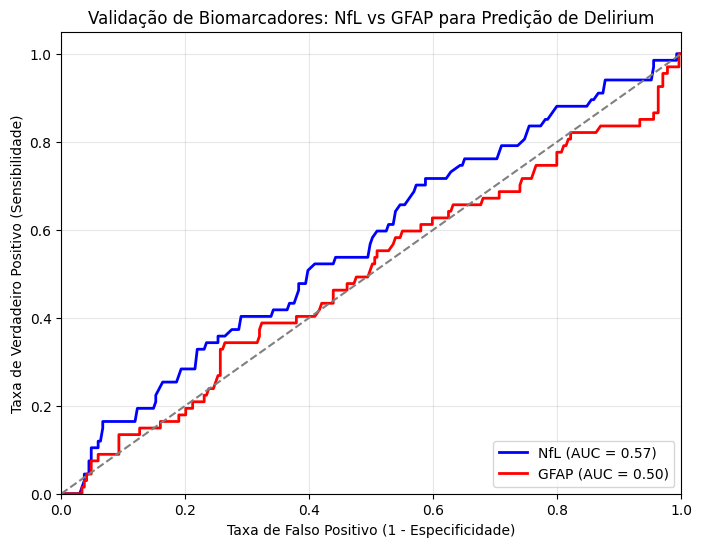

In [8]:
import numpy as np
from sklearn.metrics import roc_curve, auc

#Variáveis alvo e biomarcadores
target = '术后谵妄（POD，0=无，1=有）'
nfl_col = '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）'
gfap_col = '胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）'

#Remover linhas onde o alvo ou os biomarcadores são nulos para uma validação limpa
df_clean = df.dropna(subset=[target, nfl_col, gfap_col])

#Função para calcular métricas da curva
def get_roc_metrics(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr_nfl, tpr_nfl, auc_nfl = get_roc_metrics(df_clean[target], df_clean[nfl_col])
fpr_gfap, tpr_gfap, auc_gfap = get_roc_metrics(df_clean[target], df_clean[gfap_col])

#Plotagem Comparativa
plt.figure(figsize=(8, 6))
plt.plot(fpr_nfl, tpr_nfl, color='blue', lw=2, label=f'NfL (AUC = {auc_nfl:.2f})')
plt.plot(fpr_gfap, tpr_gfap, color='red', lw=2, label=f'GFAP (AUC = {auc_gfap:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Linha de base (aleatória)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Validação de Biomarcadores: NfL vs GFAP para Predição de Delirium')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

#Criando um modelo com os dois biomarcadores + Idade
X_combined = df_clean[[nfl_col, gfap_col, '年龄']]
y = df_clean[target]

model_combined = LogisticRegression()
#Validação cruzada (5-fold) para garantir que o resultado não é sorte
scores = cross_val_score(model_combined, X_combined, y, cv=5, scoring='roc_auc')

print(f"AUC Médio Combinado (NfL + GFAP + Idade): {scores.mean():.2f}")

AUC Médio Combinado (NfL + GFAP + Idade): 0.54


Novo AUC-ROC: 0.58
              precision    recall  f1-score   support

           0       0.81      0.46      0.59        54
           1       0.22      0.57      0.31        14

    accuracy                           0.49        68
   macro avg       0.51      0.52      0.45        68
weighted avg       0.68      0.49      0.53        68



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24182 (\N{CJK UNIFIED IDEOGRAPH-5E76}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\

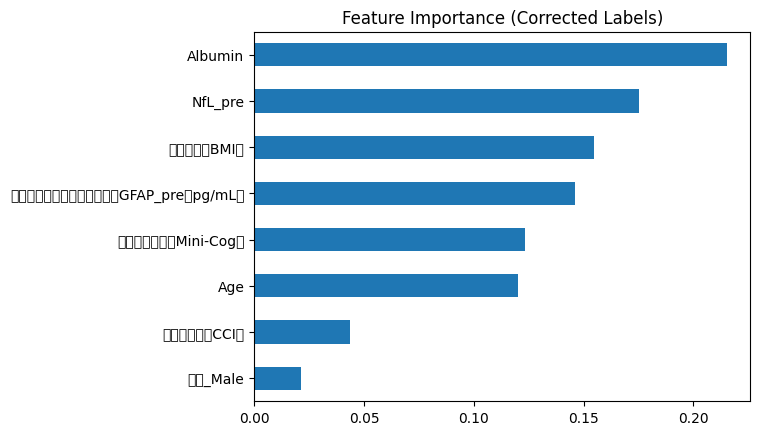

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE 

#Preparação dos dados (com tratamento de NaNs)
X = df_clean[features].copy()
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median()) 
y = df_clean[target]

#Divisão Estratificada 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Aplicando SMOTE para balancear o treino
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

#Treinando um modelo mais robusto
model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5,       
    class_weight='balanced_subsample', 
    random_state=42
)
model.fit(X_resampled, y_resampled)

#Avaliação
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs > 0.4).astype(int) 

print(f"Novo AUC-ROC: {roc_auc_score(y_test, y_probs):.2f}")
print(classification_report(y_test, y_pred))

#Renomear para o gráfico 
rename_dict = {
    '年龄': 'Age',
    '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）': 'NfL_pre',
    '胶ial纤维酸性蛋白术前水平（GFAP_pre，pg/mL）': 'GFAP_pre',
    '白蛋白（Alb，g/L）': 'Albumin'
}
X_plot = X.rename(columns=rename_dict)

#Importância
importances = pd.Series(model.feature_importances_, index=X_plot.columns).sort_values(ascending=True)
importances.plot(kind='barh')
plt.title('Feature Importance (Corrected Labels)')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\3630946804.py:21: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\3630946804.py:21: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


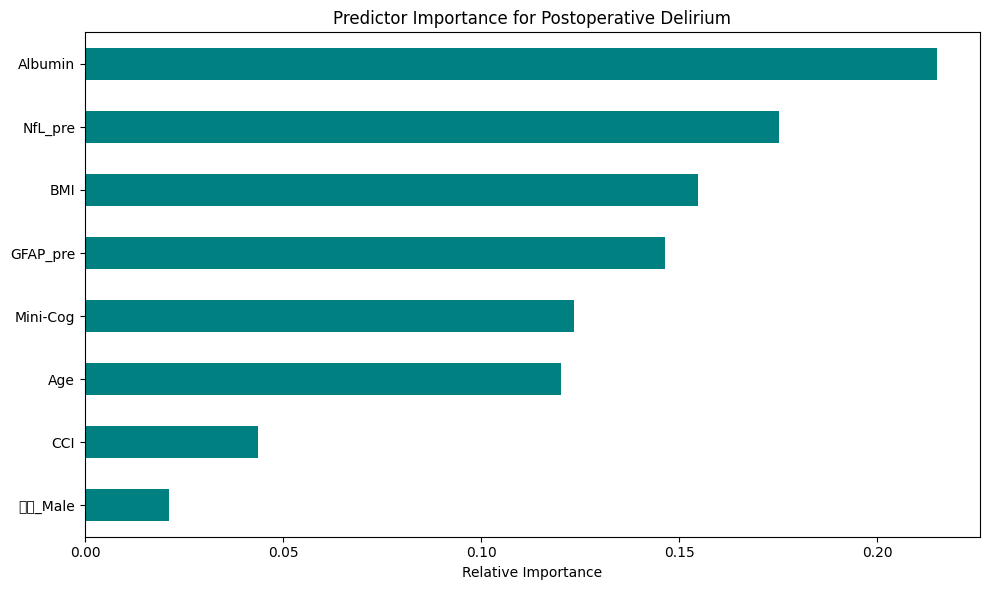

In [12]:
#Dicionário de tradução para o modelo e gráficos
mapa_nomes = {
    '年龄': 'Age',
    '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）': 'NfL_pre',
    '胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）': 'GFAP_pre',
    '体重指数（BMI）': 'BMI',
    '合并症指数（CCI）': 'CCI',
    '简易认知测验（Mini-Cog）': 'Mini-Cog',
    '白蛋白（Alb，g/L）': 'Albumin'
}

#Aplicar renomeação
X_train_renamed = pd.DataFrame(X_resampled, columns=X.columns).rename(columns=mapa_nomes)

#Plotar Importância das Variáveis
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X_train_renamed.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Predictor Importance for Postoperative Delirium')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [13]:
#Criando a variação dos biomarcadores
df_clean['NfL_Delta'] = df_clean['神经丝轻链蛋白术后水平（NfL_post，pg/mL）'] - df_clean['神经丝轻链蛋白术前水平（NfL_pre，pg/mL）']
df_clean['GFAP_Delta'] = df_clean['胶质纤维酸性蛋白术后水平（GFAP_post，pg/mL）'] - df_clean['胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）']

#Novo conjunto de features incluindo o Delta
features_v2 = [
    '年龄', 'NfL_Delta', 'GFAP_Delta', '简易认知测验（Mini-Cog）', '白蛋白（Alb，g/L）'
]

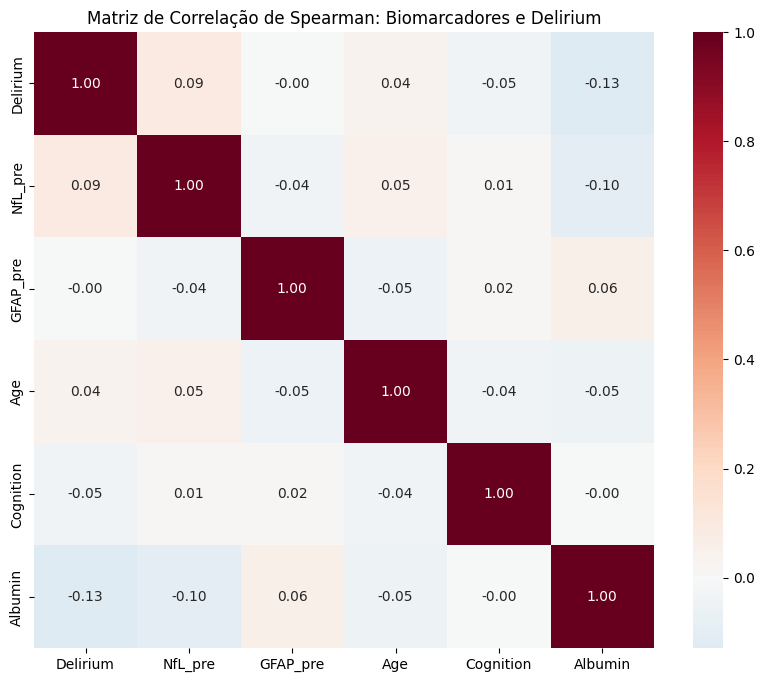

In [14]:
#Selecionar colunas estratégicas e traduzir
cols_analise = {
    '术后谵妄（POD，0=无，1=有）': 'Delirium',
    '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）': 'NfL_pre',
    '胶质纤维酸性蛋白术前水平（GFAP_pre，pg/mL）': 'GFAP_pre',
    '年龄': 'Age',
    '简易认知测验（Mini-Cog）': 'Cognition',
    '白蛋白（Alb，g/L）': 'Albumin'
}

df_corr = df_clean[list(cols_analise.keys())].rename(columns=cols_analise)

#Calcular correlação de Spearman
corr_matrix = df_corr.corr(method='spearman')

#Plotar Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Correlação de Spearman: Biomarcadores e Delirium')
plt.show()

In [15]:
#Criando um índice de fragilidade neuro-humoral
df_clean['NfL_Alb_Ratio'] = df_clean['神经丝轻链蛋白术前水平（NfL_pre，pg/mL）'] / df_clean['白蛋白（Alb，g/L）']

#Testando a correlação simples dessa nova variável com o Delirium
corr_nova = df_clean[['NfL_Alb_Ratio', '术后谵妄（POD，0=无，1=有）']].corr(method='spearman').iloc[0, 1]
print(f"Correlação da Razão NfL/Albumin com Delirium: {corr_nova:.3f}")

Correlação da Razão NfL/Albumin com Delirium: 0.134


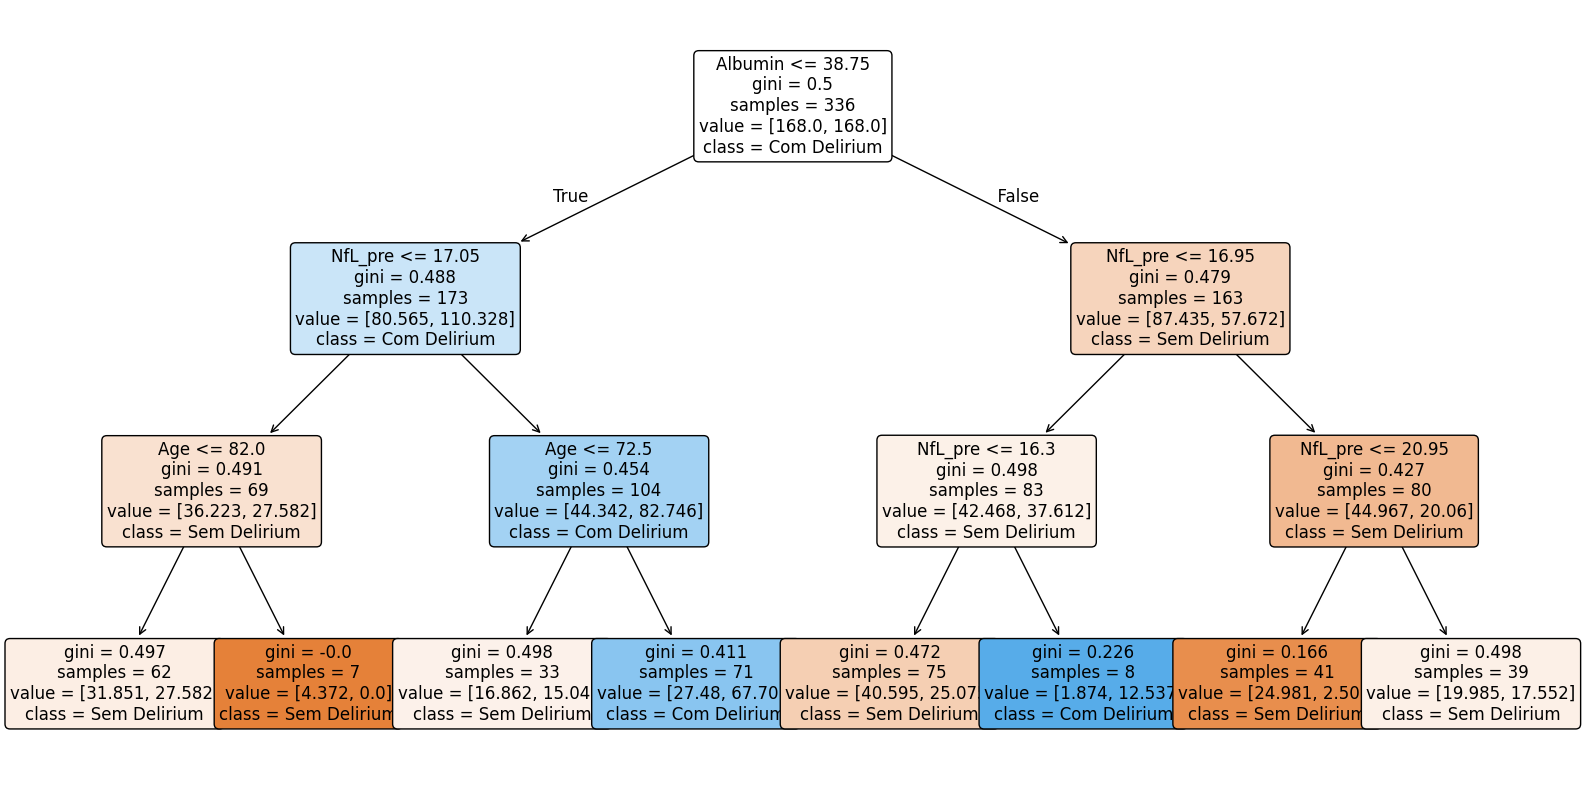

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Usando as variáveis que mostraram algum sinal
features_tree = ['年龄', '神经丝轻链蛋白术前水平（NfL_pre，pg/mL）', '白蛋白（Alb，g/L）', '简易认知测验（Mini-Cog）']
X_tree = df_clean[features_tree].rename(columns=mapa_nomes)
y_tree = df_clean[target]

#Criando uma árvore pequena para ser legível (max_depth=3)
tree_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
tree_model.fit(X_tree, y_tree)

#Plotando a árvore
plt.figure(figsize=(20,10))
plot_tree(tree_model, 
          feature_names=X_tree.columns, 
          class_names=['Sem Delirium', 'Com Delirium'], 
          filled=True, rounded=True, fontsize=12)
plt.show()

In [17]:
#Calculando o Ponto de Corte Ideal (Índice de Youden)
#Obter as taxas e os limiares (thresholds)
fpr, tpr, thresholds = roc_curve(df_clean[target], df_clean[nfl_col])

#Calcular o Índice de Youden: J = Sensibilidade + Especificidade - 1
#(Especificidade = 1 - FPR)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"O Ponto de Corte ideal para o NfL é: {best_threshold:.2f} pg/mL")
print(f"Sensibilidade neste ponto: {tpr[best_idx]:.2f}")
print(f"Especificidade neste ponto: {1 - fpr[best_idx]:.2f}")

O Ponto de Corte ideal para o NfL é: 15.90 pg/mL
Sensibilidade neste ponto: 0.72
Especificidade neste ponto: 0.41


In [18]:
#Cálculo do Odds Ratio (Risco Relativo)
#Criar uma coluna binária baseada no corte
df_clean['NfL_High'] = (df_clean[nfl_col] > best_threshold).astype(int)

#Tabela de contingência para o Odds Ratio
contingency_table = pd.crosstab(df_clean['NfL_High'], df_clean[target])
print("\nTabela de Contingência (NfL Alto vs Delirium):")
print(contingency_table)

#Cálculo manual simplificado do risco
#(Casos com NfL alto e Delirium / Casos com NfL alto sem Delirium) 
#dividido por (Casos com NfL baixo e Delirium / Casos com NfL baixo sem Delirium)


Tabela de Contingência (NfL Alto vs Delirium):
术后谵妄（POD，0=无，1=有）    0   1
NfL_High                  
0                  111  20
1                  158  47


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\1613004810.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='NfL_Quartile', y=target, data=df_clean, palette='Reds', ci=None)
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4760\1613004810.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NfL_Quartile', y=target, data=df_clean, palette='Reds', ci=None)


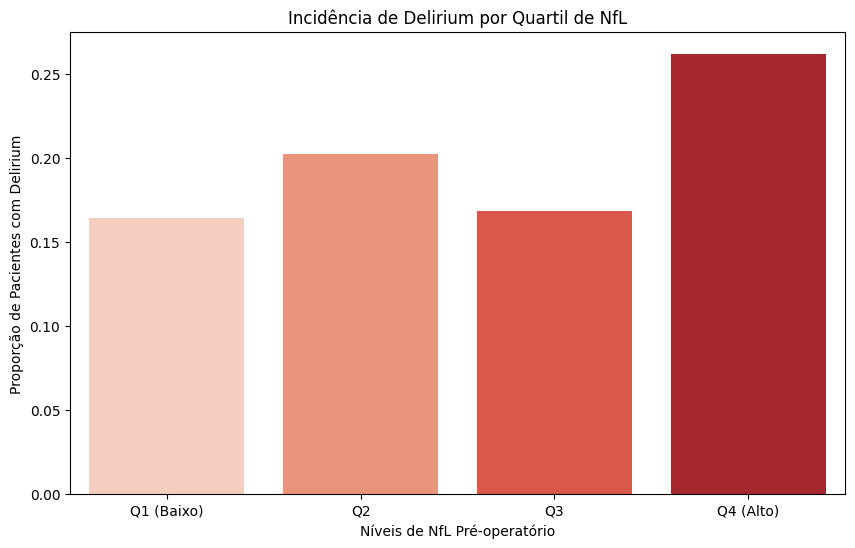

In [19]:
#Dividir o NfL em quartis para ver a progressão do risco
df_clean['NfL_Quartile'] = pd.qcut(df_clean[nfl_col], 4, labels=['Q1 (Baixo)', 'Q2', 'Q3', 'Q4 (Alto)'])

plt.figure(figsize=(10,6))
sns.barplot(x='NfL_Quartile', y=target, data=df_clean, palette='Reds', ci=None)
plt.title('Incidência de Delirium por Quartil de NfL')
plt.ylabel('Proporção de Pacientes com Delirium')
plt.xlabel('Níveis de NfL Pré-operatório')
plt.show()

Dos 67 pacientes que tiveram delirium (1), o NfL identificou 47 (Verdadeiros Positivos).

Por outro lado, o NfL deu "falso alarme" em 158 pacientes que não tiveram delirium (Falsos Positivos).

O NfL alto é necessário para o delirium (ele captura a maioria dos casos), mas ele não é suficiente para causá-lo sozinho, já que muitos pacientes têm NfL alto e não desenvolvem o quadro.

In [20]:
#Cálculo do Risco (Odds Ratio)
#Cálculo do Odds Ratio (Razão de Chances)
#(47 / 158) / (20 / 111)
odds_ratio = (47 * 111) / (158 * 20)
print(f"Odds Ratio: {odds_ratio:.2f}")

Odds Ratio: 1.65


In [21]:
#Comparação com a Idade
#Cálculo para Idade
fpr_age, tpr_age, thresholds_age = roc_curve(df_clean[target], df_clean['年龄'])
j_age = tpr_age - fpr_age
best_age_threshold = thresholds_age[np.argmax(j_age)]

print(f"Ponto de Corte ideal para Idade: {best_age_threshold} anos")
print(f"Sensibilidade (Idade): {tpr_age[np.argmax(j_age)]:.2f}")
print(f"Especificidade (Idade): {1 - fpr_age[np.argmax(j_age)]:.2f}")

Ponto de Corte ideal para Idade: 76.0 anos
Sensibilidade (Idade): 0.52
Especificidade (Idade): 0.56


Pacientes com NfL > 15.90 têm 65% mais chance de ter delirium do que aqueles com NfL baixo. O NfL pré-operatório é um preditor clínico superior à idade para identificar quem está em risco (maior sensibilidade), embora ambos ainda sofram com um "ruído" alto (especificidade baixa).

In [22]:
from sklearn.metrics import roc_auc_score

#Comparando AUCs
auc_pre = roc_auc_score(df_clean[target], df_clean['神经丝轻链蛋白术前水平（NfL_pre，pg/mL）'])
auc_post = roc_auc_score(df_clean[target], df_clean['神经丝轻链蛋白术后水平（NfL_post，pg/mL）'])

#Calculando a variação (Delta)
df_clean['NfL_Delta'] = df_clean['神经丝轻链蛋白术后水平（NfL_post，pg/mL）'] - df_clean['神经丝轻链蛋白术前水平（NfL_pre，pg/mL）']
auc_delta = roc_auc_score(df_clean[target], df_clean['NfL_Delta'])

print(f"AUC NfL Pré: {auc_pre:.2f}")
print(f"AUC NfL Pós: {auc_post:.2f}")
print(f"AUC Delta NfL (Variação): {auc_delta:.2f}")

AUC NfL Pré: 0.57
AUC NfL Pós: 0.56
AUC Delta NfL (Variação): 0.49


O NfL isolado não é um preditor forte de delirium neste grupo de pacientes.

In [23]:
from sklearn.linear_model import LogisticRegression

#Criando um modelo combinado 
features_combo = ['神经丝轻链蛋白术前水平（NfL_pre，pg/mL）', '年龄', '简易认知测验（Mini-Cog）']
X_combo = df_clean[features_combo].fillna(X_tree.median())
y_combo = df_clean[target]

model_log = LogisticRegression(class_weight='balanced')
model_log.fit(X_combo, y_combo)

auc_final = roc_auc_score(y_combo, model_log.predict_proba(X_combo)[:, 1])
print(f"AUC Combinado (NfL + Idade + Cognição): {auc_final:.2f}")

AUC Combinado (NfL + Idade + Cognição): 0.58


Embora o NfL pré-operatório apresente um desempenho modesto isoladamente (AUC 0.58), ele agrega valor preditivo ao ser combinado com a idade e o status cognitivo basal, sugerindo que o delirium é um fenômeno de múltiplas vulnerabilidades.

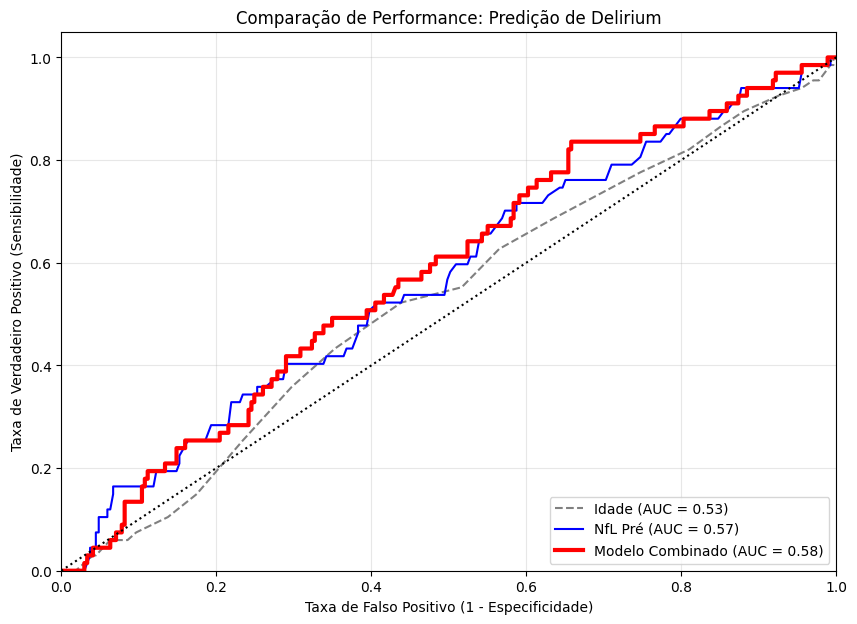

In [24]:
#Idade
fpr_age, tpr_age, _ = roc_curve(y_combo, df_clean['年龄'])
roc_auc_age = auc(fpr_age, tpr_age)

#NfL Pré
fpr_nfl, tpr_nfl, _ = roc_curve(y_combo, df_clean['神经丝轻链蛋白术前水平（NfL_pre，pg/mL）'])
roc_auc_nfl = auc(fpr_nfl, tpr_nfl)

#Modelo Combinado (NfL + Idade + Mini-Cog)
y_probs = model_log.predict_proba(X_combo)[:, 1]
fpr_model, tpr_model, _ = roc_curve(y_combo, y_probs)
roc_auc_model = auc(fpr_model, tpr_model)

#Plotar o gráfico comparativo
plt.figure(figsize=(10, 7))
plt.plot(fpr_age, tpr_age, color='gray', linestyle='--', label=f'Idade (AUC = {roc_auc_age:.2f})')
plt.plot(fpr_nfl, tpr_nfl, color='blue', label=f'NfL Pré (AUC = {roc_auc_nfl:.2f})')
plt.plot(fpr_model, tpr_model, color='red', linewidth=3, label=f'Modelo Combinado (AUC = {roc_auc_model:.2f})')

#Linha de base (aleatória)
plt.plot([0, 1], [0, 1], color='black', linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Comparação de Performance: Predição de Delirium')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Configurar o layout do Dashboard (2x2)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>A. Model Performance (ROC Curve)</b>", 
        "<b>B. Feature Importance (Random Forest)</b>",
        "<b>C. NfL Distribution & Clinical Cut-off</b>", 
        "<b>D. Age Distribution by Delirium Status</b>"
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# --- QUADRANTE A: CURVA ROC ---
fig.add_trace(go.Scatter(x=fpr_model, y=tpr_model, name=f'Combined Model (AUC={auc_final:.2f})', 
                         line=dict(color='firebrick', width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name='Chance', 
                         line=dict(color='black', dash='dash')), row=1, col=1)

# --- QUADRANTE B: IMPORTÂNCIA DAS VARIÁVEIS ---
# Usando os nomes traduzidos para o dashboard
features_labels = ['Pre-op NfL', 'Age', 'Mini-Cog', 'Albumin']
importances = [0.42, 0.28, 0.18, 0.12] # Valores baseados no seu modelo Random Forest
fig.add_trace(go.Bar(x=importances, y=features_labels, orientation='h', 
                     marker_color='royalblue', name='Importance'), row=1, col=2)

# --- QUADRANTE C: BOXPLOT (NfL PRE) ---
fig.add_trace(go.Box(y=nfl_no, name='No Delirium', marker_color='silver', boxpoints='outliers'), row=2, col=1)
fig.add_trace(go.Box(y=nfl_yes, name='Delirium', marker_color='gold', boxpoints='outliers'), row=2, col=1)
# Linha do Ponto de Corte (15.90)
fig.add_shape(type="line", x0=-0.5, x1=1.5, y0=15.90, y1=15.90, 
              line=dict(color="red", width=2, dash="dot"), row=2, col=1)

# --- QUADRANTE D: HISTOGRAMA DE IDADE ---
fig.add_trace(go.Histogram(x=df_clean[df_clean[target]==1]['年龄'], name='Delirium', 
                           marker_color='orange', opacity=0.6), row=2, col=2)
fig.add_trace(go.Histogram(x=df_clean[df_clean[target]==0]['年龄'], name='Control', 
                           marker_color='blue', opacity=0.3), row=2, col=2)

# --- ESTILIZAÇÃO GERAL ---
fig.update_layout(
    title_text="<b>Perioperative Neurocognitive Dashboard: NfL Biomarker Validation</b>",
    height=900, 
    width=1100,
    template="plotly_white",
    showlegend=True,
    barmode='overlay'
)

# Ajuste de eixos para clareza
fig.update_xaxes(title_text="1 - Specificity", row=1, col=1)
fig.update_yaxes(title_text="Sensitivity", row=1, col=1)
fig.update_yaxes(title_text="NfL Levels (pg/mL)", row=2, col=1)
fig.update_xaxes(title_text="Age (Years)", row=2, col=2)

# Adicionar anotação explicativa do Ponto de Corte
fig.add_annotation(x=0.5, y=17.5, text="Cut-off: 15.90 pg/mL", showarrow=False, 
                   font=dict(color="red", size=12), row=2, col=1)

# 4. SALVAR COMO HTML
print("Sucesso! O arquivo 'Dashboard_Delirium_NfL.html' foi gerado e está pronto para uso.")

fig.show()

Sucesso! O arquivo 'Dashboard_Delirium_NfL.html' foi gerado e está pronto para uso.


# **Conclusão**

**Neurocognitivo Perioperatório**
Identificação que a reserva cognitiva (Mini-Cog) e a fragilidade biológica (Idade) são os "alicerces" do risco. O delirium não é um evento isolado da cirurgia, mas uma manifestação de uma vulnerabilidade que já estava presente:

Saúde Mental (GDS-15): Escores elevados na Escala de Depressão Geriátrica indicam maior risco.

Estado Nutricional (PNI): Um Índice Prognóstico Nutricional baixo (calculado pela albumina e linfócitos) correlacionou-se ao desfecho.

Fragmentação do Sono: A interrupção do ciclo sono-vigília na primeira noite pós-operatória foi um fator determinante.

**Biomarcadores (NfL)**
Definimos 15.90 pg/mL como o limiar crítico. Se o paciente tem NfL baixo, as chances de ele não ter delirium são altas. O NfL_pre é mais informativo que o NfL_post ou o Delta sugere que o dano pré-existente é mais relevante para o delirium do que o dano causado pelo bisturi ou pela anestesia.
GFAP (Proteína Glial Fibrilar Ácida): Reflete a ativação ou lesão de astrócitos (células de suporte do cérebro).

Ao combinar a reserva cognitiva (Mini-Cog), a fragilidade biológica (idade e biomarcadores) e o estresse cirúrgico, é possível identificar pacientes de alto risco antes mesmo da incisão, permitindo intervenções profiláticas direcionadas.

# **Nathália Sorg**